In [101]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, root_mean_squared_error

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [102]:
base_path = r"C:\kdt_0900_pjh\machine_learning\resource\datasets"
file_name = r"titanic.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


| 컬럼명 | 데이터 타입 | 의미 및 설명 |
|---|---|---|
| pclass | 객실 등급 (Ticket class) | 1 = 1등석, 2 = 2등석, 3 = 3등석 |
| sex | 성별 | male (남성), female (여성) |
| age | 나이 | 결측치 존재, 1세 미만은 소수점 표시 |
| sibsp | 동승한 형제/자매/배우자의 수 | 0, 1, 2 ... |
| parch | 동승한 부모/자녀의 수 | 0, 1, 2 ... |
| fare | 탑승 요금 | 승객이 지불한 운임 (파운드화) |
| embarked | 탑승 항구 코드 | C = Cherbourg, Q = Queenstown, S = Southampton |
| class | 객실 등급 텍스트 | First, Second, Third (pclass와 동일 정보) |
| who | 승객 구분 | man (성인 남성), woman (성인 여성), child (아이) |
| deck | 선실 구역 번호 | A, B, C, D, E, F, G (결측치 매우 많음) |
| embark_town | 탑승 도시 이름 | Cherbourg, Queenstown, Southampton |
| alone | 혼자 탑승했는지 여부 | True (동승자 없음), False (동승자 있음) |

## [문제 0] 프로젝트 목표 정의 (5점)
1. 데이터 수집·전처리부터 모델 학습, 성능 평가까지 이어지는 머신러닝 파이프라인의 전체 구조를 명확히 제시하세요.
2. 학습(Train) 및 평가(Test) 과정에서 발생할 수 있는 데이터 누수(Data Leakage)를 방지하기 위한 데이터 분리 및 처리 전략을 포함하여 기술하세요.

### 머신러닝 전체적인 파이프라인
1. 데이터 수집 : titanic.csv를 읽어와 데이터프레임에 넣어준다.
2. 데이터 탐색 : 행/열 구조, 결측치, 이상치, 기술통계량을 확인하고, 어떤식으로 전처리할지 방향을 잡는다.
3. 모델준비(전처리, 분할) : 수치/범주형 구분, 결측치, 인코딩, 스케일링 등을 진행한고, 학습 전 학습 데이터와 테스트 데이터를 분리한다. 이때 데이터 분리를 진행하고 스케일링을 진행해야 데이터누수를 방지할 수 있다.
4. 모델학습(튜닝) : 학습 데이터로 모델을 학습하고 파라미터 또는 하이퍼파라미터 튜닝을 할지 결정 후 튜닝을 진행한다.
5. 모델평가(검증, 테스트) : 테스트 데이터를 통해 성능을 측정한다.

In [103]:
"""
데이터 누수를 방지하기 위해서는 모델 학습 전에 데이터를 분리해야한다.
학습 데이터 80%와 테스트 데이터 20%로 나누어 사용하고, 학습 데이터로 학습을 진행하고 나머지 테스트 데이터로 모델 평가를 진행한다.
이때 학습을 하고 데이터를 분리하게 되면 테스트 데이터의 일부가 학습 데이터에 포함될 수 있어 데이터 누수가 발생한다.
이는 일시적으로 테스트를 진행했을 때 성능이 좋아보일 수 있지만 새로운 데이터를 넣었을 때는 예측 성능이 떨어질 수 있다.
스케일링에서도 마찬가지로 StandardScaler를 전체 데이터 기준으로 fit하면 분리를 먼저 진행해도 데스트 데이터가 포함될 수 있다.
그래서 분리를 진행한 후에 학습 데이터로만 fit를 하고 테스트 데이터로는 transform만 해야한다.
"""
None

## [문제 1] 데이터 확인 및 EDA (10점)
1. 데이터의 행/열 개수, 컬럼명, 결측치 개수(컬럼별) 요약을 작성하고, 이상치를 탐색를 각 컬럼의 이상치로 판단하거나 이상치로 보지 않은 근거를 서술하세요(5점)
2. Survived 클래스 비율(생존/사망 비율)을 계산하고 해석하세요. (5점)

In [104]:
# 데이터의 행/열 갯수
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [105]:
# 컬럼명
df.columns 

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [106]:
# 컬럼별 결측치
# 나이 177개, 객실번호 687개
df.isna().sum() 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [107]:
# 기술통계량
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


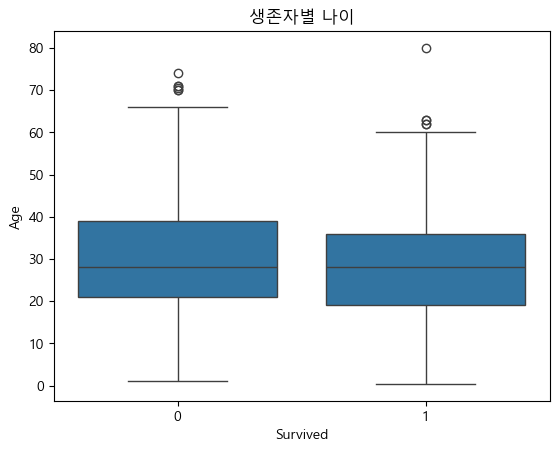

In [108]:
sns.boxplot(df, x="Survived", y="Age")
plt.title("생존자별 나이")
plt.show()

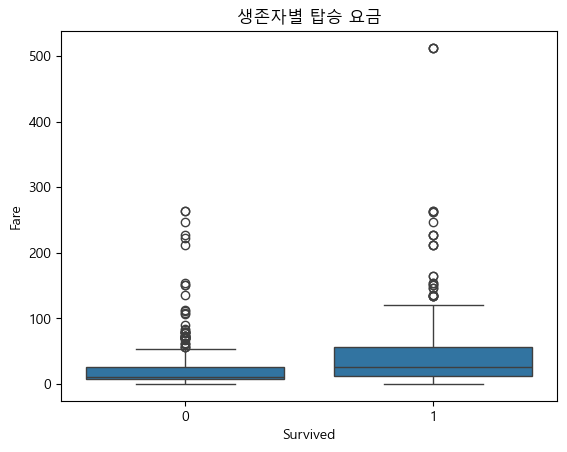

In [109]:
sns.boxplot(df, x="Survived", y="Fare")
plt.title("생존자별 탑승 요금")
plt.show()

### 컬럼별 이상치 판단
기술통계량 및 boxplot을 봤을 때 나이 및 탑승 요금에서 이상치가 있다고 판단이 된다.
하지만 외국은 애기가 태어났을 때 0세부터 나이를 세기 때문에 0.4세는 갓난애기로 판단하여 이상치로 판단하지 않는다.
탑승 요금 또한 부자들이 많이 탑승한 만큼 큰 금액을 지불하고 티켓을 구매한 사람이 있을 것이라 판단하여 이상치로 판단하지 않는다.

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


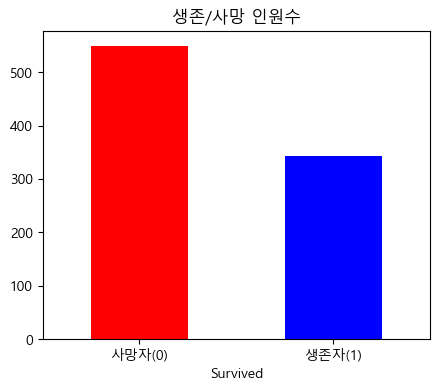

In [110]:
print(df["Survived"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
df["Survived"].value_counts().plot(kind="bar", color=["red", "blue"])
plt.xticks([0, 1], ["사망자(0)", "생존자(1)"], rotation=0)
plt.title("생존/사망 인원수")
plt.show()

### 타이타닉에서 사망자는 총 61.6%, 생존자는 총 38.4%인 것을 확인 할 수 있다.

## [문제 2] 다음 조건을 만족하도록 전처리를 설계하세요. (20점)
1. 수치형/범주형 변수를 구분하라. (5점)
2. 결측치 처리 전략을 각각 제시하세요. (예: age, embarked 등) (5점)
3. 범주형 인코딩 방법(원-핫 등)과 수치형 스케일링 필요 여부를 판단하고 근거를 서술하세요. (5점)
4. 스케일링을 표준화로 할지 정규화로 할지 판단 근거를 서술하세요. (5점)

In [111]:
# 수치형: PassengerId, SibSp, Age, Parch, Fare
# 범주형: Survived, Pclass, Sex, Embarked

In [112]:
"""
Age같은 경우 177개의 결측치가 있다
평균으로 결측값을 채우게 되면 연세가 많으신 분들 때문에 한쪽으로 칠 수 있어 이상치에 민감하지 않은 중앙값으로 결측값을 채운다.

Embarked같은 경우 2개의 결측치가 있다.
전체 데이터 중 2개의 결측치는 매우 적은 영향을 끼치기 때문에 최빈값으로 결측값을 채운다.
"""
None

In [113]:
"""
범주형 같은 Survived, Pclass, Sex은 인코딩이 필요없지만 Embarked같은 경우 C, Q, S로 값이 세개라 
원-핫 인코딩이 필요하다.

수치형 데이터들의 단위가 다 다르기 때문에 특정 데이터에 많이 치우칠 수 있다.
이를 방지하기 위해서 스케일링이 필요하다.
"""
None

In [114]:
"""
Fare 값을 보면 최소값이 0, 최대값이 512로 50%가 14.5밖에 되지 않는다. 만약 정규화를 쓰게 된다면
512가 1이 되기 때문에 대부분의 값들은 0쪽에 몰려있게 된다. 그렇기 때문에 표준화를 쓰는 것이 맞다.
"""
None

## [문제 3] 데이터 분리 및 검증 전략 (15점)
1. 학습/테스트 데이터를 분리하세요. (7점)
2. 분리 시 stratify(계층화) 적용 여부를 결정하고 이유를 설명하세요. (8점)

In [115]:
titanic_df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].mean())
titanic_df["Age"] = titanic_df["Age"].astype(int)
titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})
titanic_df = pd.get_dummies(titanic_df, columns=["Embarked"], drop_first=True, dtype=int)

In [116]:
X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 9) (179, 9) (712,) (179,)


In [117]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [118]:
"""
stratify를 적용한다.
대부분의 데이터의 비율을 보면 반반이 아니다. 무작위로 데이터를 나누게 되면 운이 나쁠 경우 한쪽으로
학습 데이터나 테스트 데이터가 몰릴 수 있다 그렇기 때문에 stratify를 적용해야한다.
"""
None

운이 나빠서 한쪽으로 치우친게 아니라 한쪽으로 편향되게 값이 전달되면 성능자체가 떨어질 수 있기 때문에 stratify를 적용하는 것이 좋다.

## [문제 4] 모델 학습 (20점)
1. 기본 모델 1개 이상: (예: Logistic Regression, Lasso, Ridge, RandomForest 등) (5점)
2. 모델 학습 및 예측까지 이어지는 전체 흐름과 각 단계별 핵심 코드를 작성하세요. (10점)
3. 파라미터와 하이퍼파라미터의 차이를 서술하고, 하이퍼파라미터 튜닝을 “최소 1개 파라미터”만이라도 시도하세요.(5점)

In [119]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("train score:", round(lr.score(X_train_scaled, y_train), 4))
print("test score:", round(lr.score(X_test_scaled, y_test), 4))

train score: 0.8034
test score: 0.7877


In [120]:
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=C, max_iter=1000, random_state=2026)
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    print(f"C={C:<6} train={train_acc:.4f}  test={test_acc:.4f}")

C=0.01   train=0.8104  test=0.7821
C=0.1    train=0.7992  test=0.7877
C=1      train=0.8034  test=0.7877
C=10     train=0.8034  test=0.7877
C=100    train=0.8034  test=0.7877


In [121]:
"""
파라미터는 모델이 데이터를 학습하면서 스스로 값을 찾아내지만 
하이퍼파라미터는 학습을 하기 전에 사람이 미리 값을 정해준다.
"""
None

## [문제 5] 평가 및 리포트 (20점)
1. Accuracy, Precision, Recall, F1 중 최소 2개 이상 사용하여 모델을 평가하세요. (10점)
2. Confusion Matrix 해석하세요. (5점)
3. 어떤 오류가 더 치명적인지(예: 생존자를 사망으로 예측 vs 반대) 상황을 가정해 서술하세요. (5점)

In [122]:
print(f"Accuracy 테스트 정확도: {accuracy_score(y_test, y_pred) * 100}")
print(f"F1 테스트: {f1_score(y_test, y_pred) * 100}", end="\n\n")

print(classification_report(y_test, y_pred, target_names=["사망(0)", "생존(1)"]))

Accuracy 테스트 정확도: 78.77094972067039
F1 테스트: 72.05882352941177

              precision    recall  f1-score   support

       사망(0)       0.82      0.84      0.83       110
       생존(1)       0.73      0.71      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



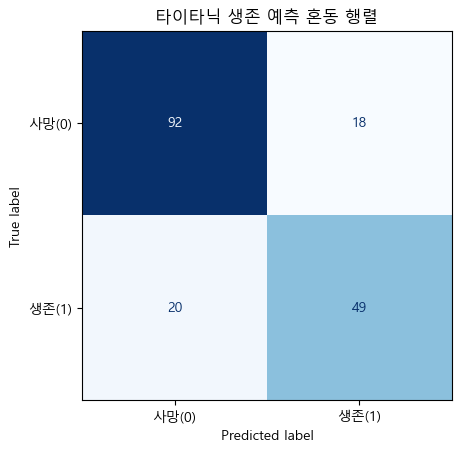

In [123]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["사망(0)", "생존(1)"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("타이타닉 생존 예측 혼동 행렬")
plt.show()

In [124]:
"""
실제 사망한 110명 중 92명은 예측에 성공했고 18명의 생존자는 잘못 예측하였다.
실제 생존한 69명 중 49명은 예측에 성공했고, 20명은 사망으로 잘못 예측하였다.
"""
None

In [125]:
"""
실제 생존자를 사망으로 잘못 예측한 것이 더 치명적인 오류이다.
생존가능성이 있는 사람을 사망으로 판단하게 되면 생명을 살릴 수 있었지만 지원을 가지않아 구하지 못하게 된다.
반대로 사망자를 생존으로 판단하게 되면 인력낭비를 하게 되지만 딱 그정도의 손해로 끝이난다.
"""
None

## [문제 6] 최종 제출물 구성 (10점)
1. 데이터 요약(EDA 결과 핵심 3가지)하여 서술하세요. (3점)
2. 전처리 전략 요약(결측/인코딩/스케일링)하여 서술하세요. (3점)
3. 모델 선택 이유와 학습 설정(튜닝 포함)을 요약하여 서술하세요. (2점)
4. 최종 성능 지표 및 해석과 개선 아이디어 1개 이상 서술하세요. (2점)

In [126]:
"""
1. 총 891명 중에서 사망자 61.6%, 생존자 38.4%
2. Age(177개), Embarked(2개), Cabin(687)의 결측치가 있었고, Cabin은 결측치가 너무 많아 제외하였다.
3. 성별은 인-핫 인코딩을 활용하여 0과 1의 값으로 변경하였다.
"""
None

In [127]:
"""
문자열 데이터 및 불필요한 데이터(PassengerId, Name, Ticket, Cabin, Embarked)를 제거하였다.
Age는 중앙값, Embarked는 최빈값으로 결측치를 해웠고, Sex는 0과 1, Embarked는 원-핫 인코딩을 활용했다. 
StandardScaler()으로 표준화를 적용했다.
"""
None

In [128]:
"""
이진 분류와 로지스틱 회귀를 모델로 선택했다. 출력값을 0과 1이 아니라 확률값으로 제공하여 상황에 맞게
임계값을 조절할 수 있다는 장점이 있기 때문이다. 즉 어떤 특성이 생존에 영향을 줬는지 바로 확인 할 수 있다.
하이퍼파라미터는 0.01부터 100까지 바꿔가며 테스트 점수를 비교했다.
"""
None

In [129]:
"""
테스트 정확도 78.7%, F1 72.0%가 나왔다. 정확도는 준수한 편이지만 F1의 값이 6%나 낮게 측정 된 것을 보아 생존/사망
을 제대로 맞추지 못했다고 판단된다.
개선 아이디어로는 SibSp, Parch를 합쳐 FamilySize를 만든 것 외에 새로운 파생 변수를 추가하여 재현율을 높이는 방안을 생각해봤다.
"""
None